# NCR RIDE BOOKINGS - DATA ANALYSIS PROJECT



In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings_import = __import__('warnings')
warnings_import.filterwarnings('ignore')

In [34]:
# Set a nice style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

## LOAD THE DATA & DATA DISCRIPTION

In [35]:
df = pd.read_csv(r"ncr_ride_bookings.csv")

In [36]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn Names:")
print(df.columns.tolist())

Rows: 150000, Columns: 21

Column Names:
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']


In [37]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [38]:
df.dtypes

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

In [39]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [40]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

## CLEANING THE DATA

### FIX DATA TYPES

In [42]:
# dates and times
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time

# Strip extra quotes from ID columns (artifact of CSV encoding)
df['Booking ID'] = df['Booking ID'].str.strip('"')
df['Customer ID'] = df['Customer ID'].str.strip('"')

# Extract useful time features
df['Month']     = df['Date'].dt.month
df['Month_Name']= df['Date'].dt.strftime('%b')
df['Day_of_Week']= df['Date'].dt.day_name()
df['Hour']      = pd.to_datetime(df['Time'].astype(str)).dt.hour

# Bin hours into time-of-day
def time_of_day(h):
    if 5 <= h < 12:  return 'Morning'
    if 12 <= h < 17: return 'Afternoon'
    if 17 <= h < 21: return 'Evening'
    return 'Night'

df['Time_of_Day'] = df['Hour'].apply(time_of_day)

print('Data types fixed ')
df[['Date','Month','Day_of_Week','Hour','Time_of_Day']].head()

Data types fixed 


,Date,Month,Day_of_Week,Hour,Time_of_Day
0,2024-03-23,3,Saturday,12,Afternoon
1,2024-11-29,11,Friday,18,Evening
2,2024-08-23,8,Friday,8,Morning
3,2024-10-21,10,Monday,17,Evening
4,2024-09-16,9,Monday,22,Night


### HANDLING MISSING VALUES

In [43]:
# Structural NaNs — fill with meaningful labels
df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna('N/A')
df['Driver Cancellation Reason']        = df['Driver Cancellation Reason'].fillna('N/A')
df['Incomplete Rides Reason']           = df['Incomplete Rides Reason'].fillna('N/A')
df['Payment Method']                    = df['Payment Method'].fillna('Unknown')

# Numeric flags (0/1 columns) — fill with 0
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0)
df['Cancelled Rides by Driver']   = df['Cancelled Rides by Driver'].fillna(0)
df['Incomplete Rides']            = df['Incomplete Rides'].fillna(0)

# Avg VTAT — fill with median (for non-completed rides that still have partial data)
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].median())

# Booking Value, Ride Distance, Ratings, Avg CTAT — keep NaN; these only apply to completed rides
# We create a clean 'completed' subset for analyses that need these
df_completed = df[df['Booking Status'] == 'Completed'].copy()

print(f'Full dataset: {df.shape[0]:,} rows')
print(f'Completed rides subset: {df_completed.shape[0]:,} rows')
print('Missing value handling complete ')

Full dataset: 150,000 rows
Completed rides subset: 93,000 rows
Missing value handling complete 


In [44]:
# Verify no unexpected nulls remain
still_missing = df.isnull().sum()
still_missing[still_missing > 0]

Avg CTAT           48000
Booking Value      48000
Ride Distance      48000
Driver Ratings     57000
Customer Rating    57000
dtype: int64

## HANDLING DUPLICATES

In [45]:
full_dups = df.duplicated().sum()
print(f'Full-row duplicates: {full_dups}')

Full-row duplicates: 0


In [46]:
# ── 4.2  Booking ID duplicates ─────────────────────────────────────────────
booking_dups = df['Booking ID'].duplicated().sum()
print(f'Duplicate Booking IDs: {booking_dups}')

# Inspect a sample of duplicate booking IDs
dup_ids = df[df['Booking ID'].duplicated(keep=False)]
print(f'\nRows involved in duplicate Booking IDs: {len(dup_ids)}')
dup_ids.sort_values('Booking ID').head(8)

Duplicate Booking IDs: 1233

Rows involved in duplicate Booking IDs: 2457


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Month,Month_Name,Day_of_Week,Hour,Time_of_Day
81334,2024-10-15,18:17:23,CNR1026036,Completed,CID6480133,Go Mini,Khandsa,Ashok Vihar,3.8,43.3,...,102.0,36.51,4.9,4.2,UPI,10,Oct,Tuesday,18,Evening
9192,2024-07-21,17:59:41,CNR1026036,No Driver Found,CID6974869,Go Mini,Seelampur,Nehru Place,8.3,NaN,...,NaN,NaN,NaN,NaN,Unknown,7,Jul,Sunday,17,Evening
9587,2024-12-17,19:19:02,CNR1029172,Completed,CID6382731,Auto,Inderlok,Laxmi Nagar,6.9,34.4,...,332.0,36.38,4.3,4.3,UPI,12,Dec,Tuesday,19,Evening
1353,2024-01-19,17:00:57,CNR1029172,Incomplete,CID2615731,Bike,Jhilmil,Narsinghpur,4.7,26.7,...,429.0,16.16,NaN,NaN,UPI,1,Jan,Friday,17,Evening
82029,2024-11-05,16:50:20,CNR1051228,Completed,CID3177617,Auto,Dwarka Sector 21,Nehru Place,8.5,24.8,...,246.0,4.80,4.6,4.5,UPI,11,Nov,Tuesday,16,Afternoon
110412,2024-01-31,08:42:04,CNR1051228,Completed,CID5242056,Premier Sedan,Arjangarh,Yamuna Bank,14.2,25.4,...,930.0,13.06,3.4,4.2,Cash,1,Jan,Wednesday,8,Morning
87333,2024-04-20,23:16:21,CNR1056023,Completed,CID9367665,Premier Sedan,Badshahpur,Sultanpur,7.1,25.7,...,116.0,46.54,3.8,5.0,Credit Card,4,Apr,Saturday,23,Night
120008,2024-07-07,17:18:49,CNR1056023,Incomplete,CID4890470,Go Sedan,Meerut,Tilak Nagar,6.6,24.2,...,420.0,5.13,NaN,NaN,Uber Wallet,7,Jul,Sunday,17,Evening


In [47]:
# ── 4.3  Investigate whether duplicates are truly identical ───────────────
dup_check = dup_ids.groupby('Booking ID').apply(
    lambda x: (x.nunique() > 1).any()
).rename('has_different_values')

print(f'Duplicate IDs with DIFFERENT values (possible data issue): {dup_check.sum()}')
print(f'Duplicate IDs with ALL identical values: {(~dup_check).sum()}')

Duplicate IDs with DIFFERENT values (possible data issue): 1224
Duplicate IDs with ALL identical values: 0


In [48]:
# ── 4.4  Resolution strategy ──────────────────────────────────────────────
# Keep the first occurrence for each Booking ID (conservative approach)
df_clean = df.drop_duplicates(subset='Booking ID', keep='first').reset_index(drop=True)
df_completed_clean = df_clean[df_clean['Booking Status'] == 'Completed'].copy()

print(f'Rows before dedup: {len(df):,}')
print(f'Rows after dedup:  {len(df_clean):,}')
print(f'Rows removed:      {len(df) - len(df_clean):,}')

Rows before dedup: 150,000
Rows after dedup:  148,767
Rows removed:      1,233


## HANDLING OUTLIERS

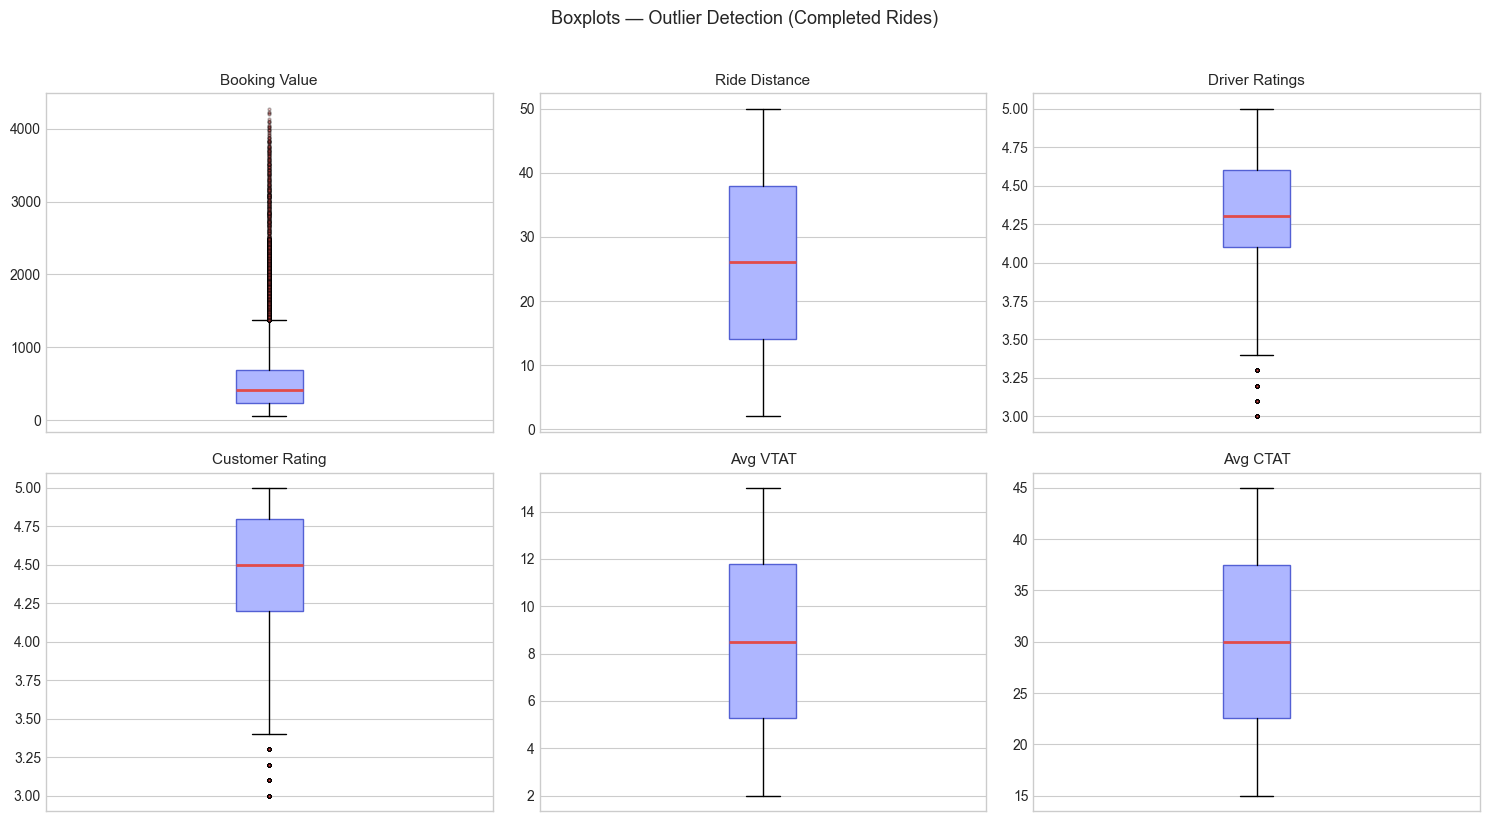

In [49]:
numeric_cols = ['Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Avg VTAT', 'Avg CTAT']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df_completed_clean[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AEB6FF', color='#5360D4'),
                    medianprops=dict(color='#E24B4A', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='#E24B4A', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xticks([])

plt.suptitle('Boxplots — Outlier Detection (Completed Rides)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [50]:
# ── 5.2  IQR-based outlier count ─────────────────────────────────────────
def iqr_outlier_report(df, cols):
    rows = []
    for col in cols:
        s = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append({'Column': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                     'Lower Fence': lower, 'Upper Fence': upper,
                     'Outlier Count': n_out, 'Outlier %': round(n_out / len(s) * 100, 2)})
    return pd.DataFrame(rows).set_index('Column')

iqr_report = iqr_outlier_report(df_completed_clean, numeric_cols)
iqr_report

,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
Column,,,,,,,
Booking Value,234.0,688.00,454.00,-447.000,1369.000,3125,3.39
Ride Distance,14.1,37.95,23.85,-21.675,73.725,0,0.00
Driver Ratings,4.1,4.60,0.50,3.350,5.350,5162,5.60
Customer Rating,4.2,4.80,0.60,3.300,5.700,3237,3.51
Avg VTAT,5.3,11.80,6.50,-4.450,21.550,0,0.00
Avg CTAT,22.6,37.50,14.90,0.250,59.850,0,0.00


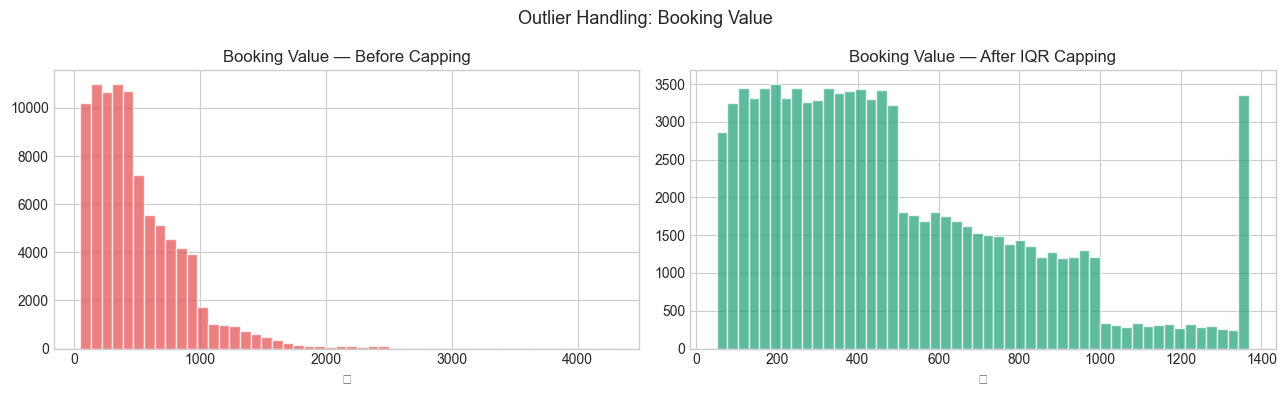

Before: max = ₹4277
After:  max = ₹1369


In [51]:
# ── 5.3  Outlier handling ─────────────────────────────────────────────────
# Strategy:
#   - Booking Value: cap at upper fence (high fares are possible but extreme ones may be errors)
#   - Driver / Customer Ratings: keep as-is (scale is 1–5, legitimate range)
#   - Ride Distance, VTAT, CTAT: no outliers detected via IQR — no action needed

def cap_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower=lower, upper=upper)

df_completed_clean['Booking Value_capped'] = cap_outliers_iqr(df_completed_clean['Booking Value'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.hist(df_completed_clean['Booking Value'].dropna(), bins=50, color='#E24B4A', alpha=0.7, edgecolor='white')
ax1.set_title('Booking Value — Before Capping')
ax1.set_xlabel('₹')

ax2.hist(df_completed_clean['Booking Value_capped'].dropna(), bins=50, color='#1D9E75', alpha=0.7, edgecolor='white')
ax2.set_title('Booking Value — After IQR Capping')
ax2.set_xlabel('₹')

plt.suptitle('Outlier Handling: Booking Value', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Before: max = ₹{df_completed_clean['Booking Value'].max():.0f}")
print(f"After:  max = ₹{df_completed_clean['Booking Value_capped'].max():.0f}")

In [52]:
# Skewness and Kurtosis summary
stats_df = pd.DataFrame({
    'Mean':     df_completed_clean[numeric_cols].mean().round(2),
    'Median':   df_completed_clean[numeric_cols].median().round(2),
    'Std Dev':  df_completed_clean[numeric_cols].std().round(2),
    'Skewness': df_completed_clean[numeric_cols].skew().round(3),
    'Kurtosis': df_completed_clean[numeric_cols].kurtosis().round(3),
})
stats_df

,Mean,Median,Std Dev,Skewness,Kurtosis
Booking Value,508.19,414.00,396.26,2.303,10.025
Ride Distance,26.00,26.03,13.82,-0.003,-1.196
Driver Ratings,4.23,4.30,0.44,-0.656,0.282
Customer Rating,4.40,4.50,0.44,-0.885,0.647
Avg VTAT,8.51,8.50,3.75,-0.000,-1.197
Avg CTAT,30.03,30.00,8.65,-0.003,-1.197


## UNIVARIATE ANALYSIS

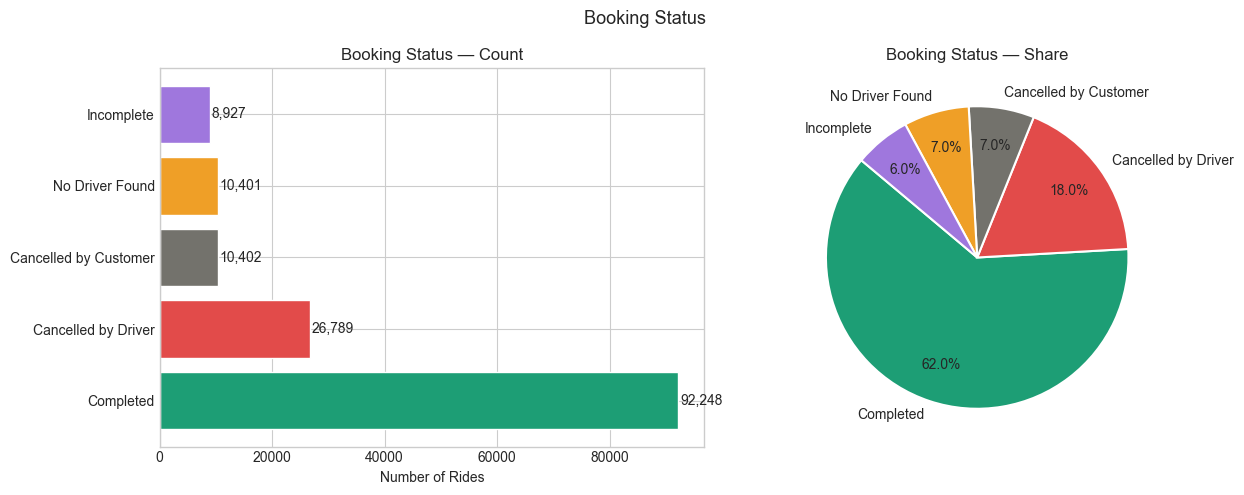

In [53]:
# Booking Status distribution
status_counts = df_clean['Booking Status'].value_counts()
colors = ['#1D9E75','#E24B4A','#73726C','#EF9F27','#9F77DD']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.barh(status_counts.index, status_counts.values, color=colors, edgecolor='white')
for i, v in enumerate(status_counts.values):
    ax1.text(v + 300, i, f'{v:,}', va='center', fontsize=10)
ax1.set_title('Booking Status — Count', fontsize=12)
ax1.set_xlabel('Number of Rides')

ax2.pie(status_counts.values, labels=status_counts.index, colors=colors,
        autopct='%1.1f%%', startangle=140, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Booking Status — Share', fontsize=12)

plt.suptitle('Booking Status', fontsize=13)
plt.tight_layout()
plt.show()

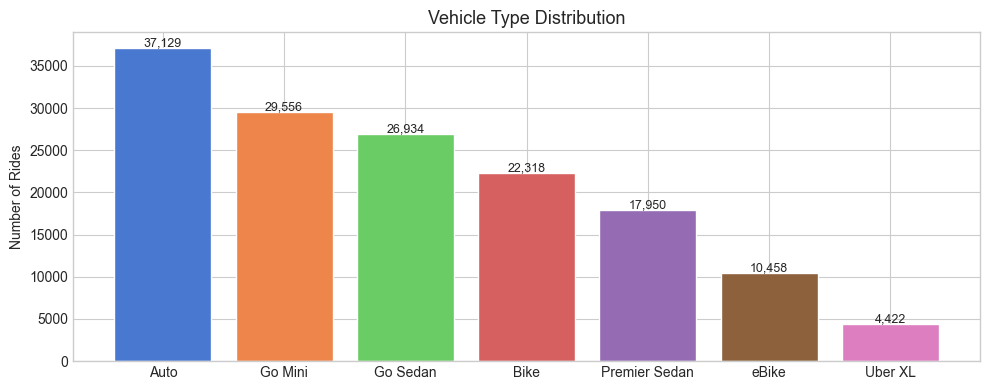

In [54]:
# Vehicle Type distribution
vt_counts = df_clean['Vehicle Type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(vt_counts.index, vt_counts.values, color=sns.color_palette('muted', len(vt_counts)), edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,.0f}', ha='center', fontsize=9)
ax.set_title('Vehicle Type Distribution', fontsize=13)
ax.set_ylabel('Number of Rides')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

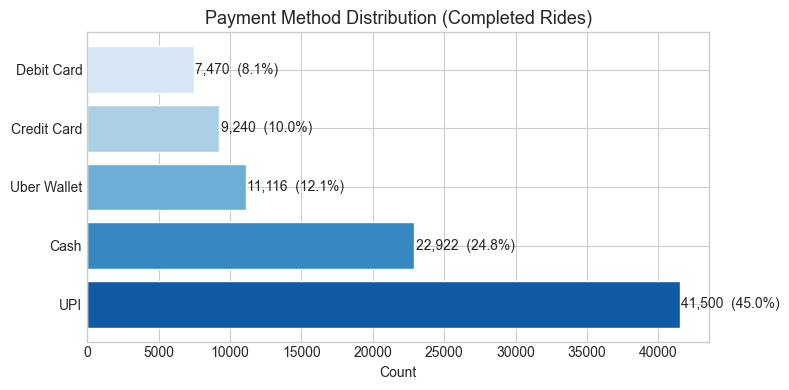

In [55]:
# Payment Method distribution
pm_counts = df_completed_clean['Payment Method'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(pm_counts.index, pm_counts.values, color=sns.color_palette('Blues_r', len(pm_counts)), edgecolor='white')
for i, v in enumerate(pm_counts.values):
    ax.text(v + 100, i, f'{v:,}  ({v/pm_counts.sum()*100:.1f}%)', va='center', fontsize=10)
ax.set_title('Payment Method Distribution (Completed Rides)', fontsize=13)
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

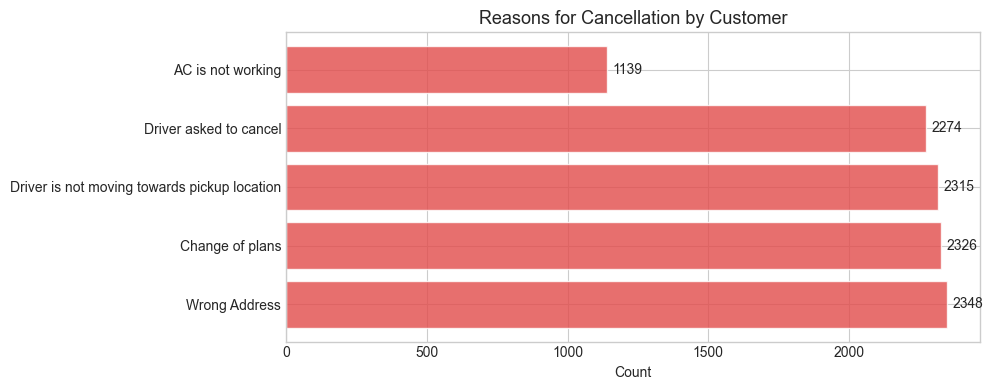

In [56]:
# Cancellation reasons — Customer
cust_cancel = df_clean[df_clean['Reason for cancelling by Customer'] != 'N/A']['Reason for cancelling by Customer'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(cust_cancel.index, cust_cancel.values, color='#E24B4A', alpha=0.8, edgecolor='white')
for i, v in enumerate(cust_cancel.values):
    ax.text(v + 20, i, str(v), va='center', fontsize=10)
ax.set_title('Reasons for Cancellation by Customer', fontsize=13)
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

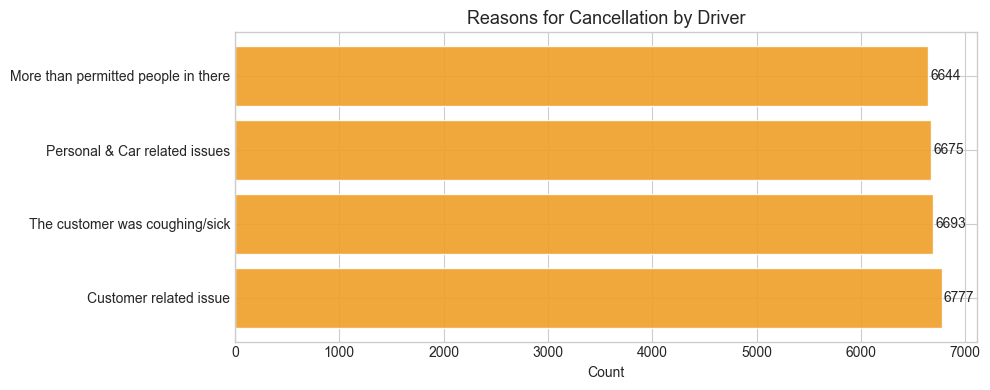

In [57]:
# Cancellation reasons — Driver
drv_cancel = df_clean[df_clean['Driver Cancellation Reason'] != 'N/A']['Driver Cancellation Reason'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(drv_cancel.index, drv_cancel.values, color='#EF9F27', alpha=0.9, edgecolor='white')
for i, v in enumerate(drv_cancel.values):
    ax.text(v + 20, i, str(v), va='center', fontsize=10)
ax.set_title('Reasons for Cancellation by Driver', fontsize=13)
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

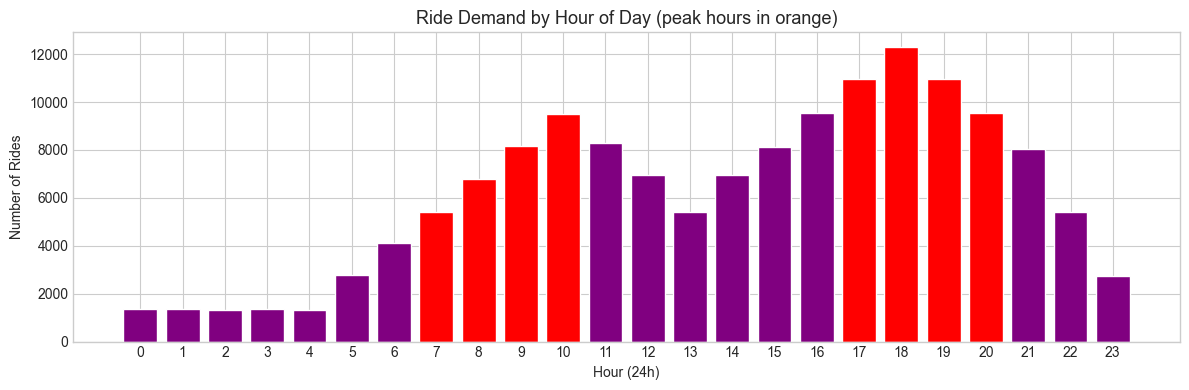

In [58]:
# Rides by Hour of Day
hour_counts = df_clean['Hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hour_counts.index, hour_counts.values,
       color=['red' if (7 <= h <= 10 or 17 <= h <= 20) else 'purple' for h in hour_counts.index],
       edgecolor='white')
ax.set_title('Ride Demand by Hour of Day (peak hours in orange)', fontsize=13)
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Number of Rides')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

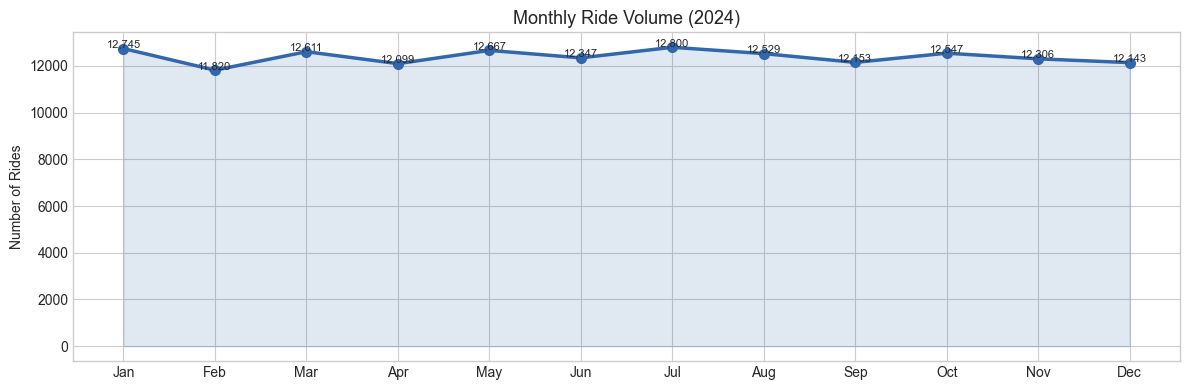

In [59]:
# Monthly ride volume
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df_clean.groupby('Month_Name').size().reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2.5, color='#3266AD', markersize=7)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='#3266AD')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index)
ax.set_title('Monthly Ride Volume (2024)', fontsize=13)
ax.set_ylabel('Number of Rides')
for i, v in enumerate(monthly.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## BIVARIATE ANALYSIS

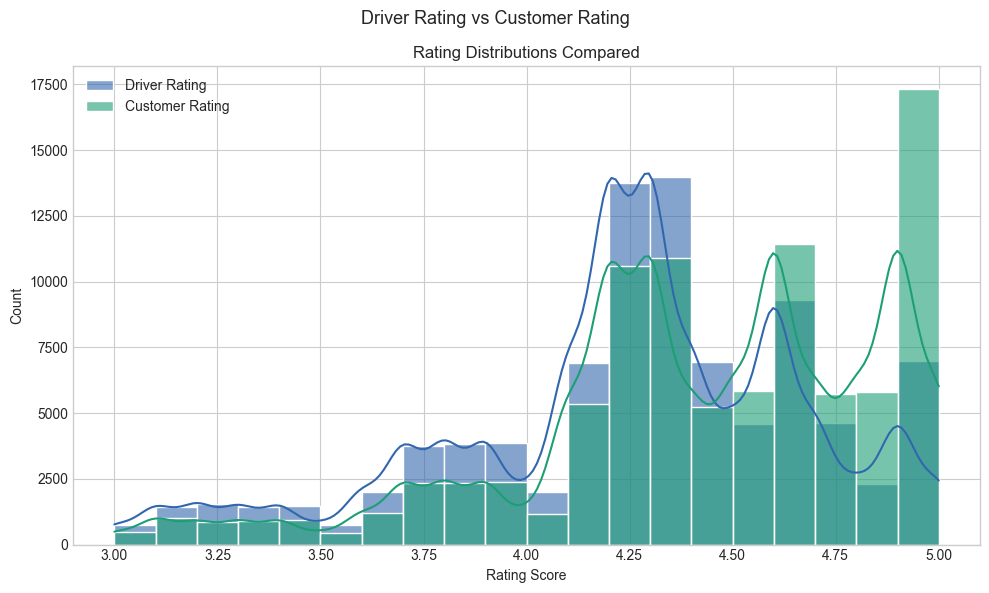

In [60]:

# ── 7.3  Driver Rating vs Customer Rating ─────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Rating distributions side by side - using sns.histplot instead of axes.histplot
sns.histplot(df_completed_clean['Driver Ratings'].dropna(), bins=20, alpha=0.6, label='Driver Rating', color='#3266AD', edgecolor='white', ax=axes,kde = True)
sns.histplot(df_completed_clean['Customer Rating'].dropna(), bins=20, alpha=0.6, label='Customer Rating', color='#1D9E75', edgecolor='white', ax=axes,kde = True)
axes.set_title('Rating Distributions Compared')
axes.set_xlabel('Rating Score') 
axes.legend()

plt.suptitle('Driver Rating vs Customer Rating', fontsize=13)
plt.tight_layout()
plt.show()

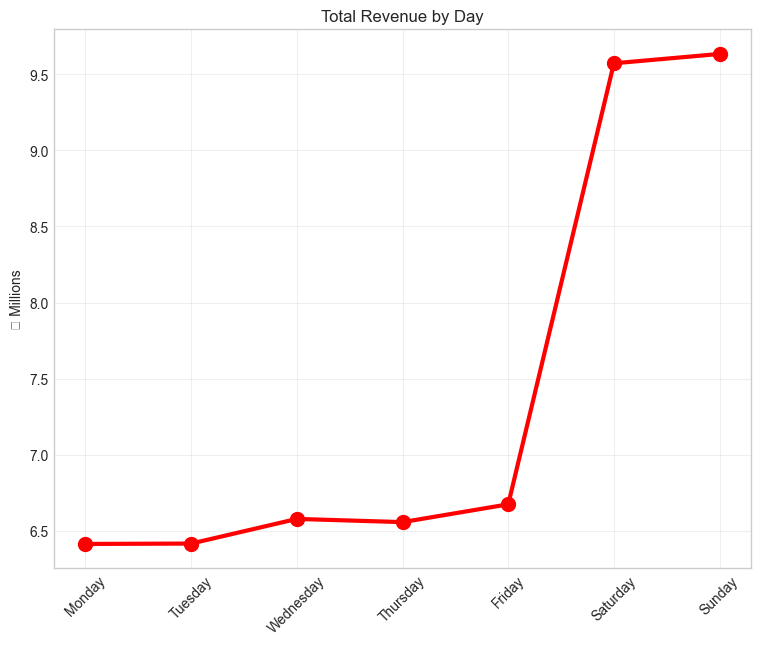

In [61]:
fig, ax = plt.subplots(figsize=(9, 7))
daywise = df.groupby('Day_of_Week')['Booking Value'].agg(['mean', 'sum', 'count'])
daywise = daywise.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.plot(daywise.index, daywise['sum']/1000000, 'ro-', linewidth=3, markersize=10)
plt.title('Total Revenue by Day')
plt.ylabel('₹ Millions')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

## MULTIVARIATE ANALYSIS

In [64]:
daywise

,mean,sum,count
Day_of_Week,,,
Monday,438.650551,6414387.0,14623
Tuesday,442.452596,6416890.0,14503
Wednesday,451.746687,6578787.0,14563
Thursday,452.222605,6557680.0,14501
Friday,459.936397,6674597.0,14512
Saturday,649.817028,9571155.0,14729
Sunday,661.176951,9632687.0,14569


In [65]:
top_locations

,Ride_Count,Avg_Value
Pickup Location,,
Khandsa,599,515.757930
Barakhamba Road,591,521.209814
Subhash Chowk,575,514.850435
Madipur,571,490.215412
Mehrauli,567,477.063492
Kanhaiya Nagar,566,481.915194
Ashok Park Main,565,510.847788
Dwarka Sector 21,563,508.539964
Badarpur,562,525.457295


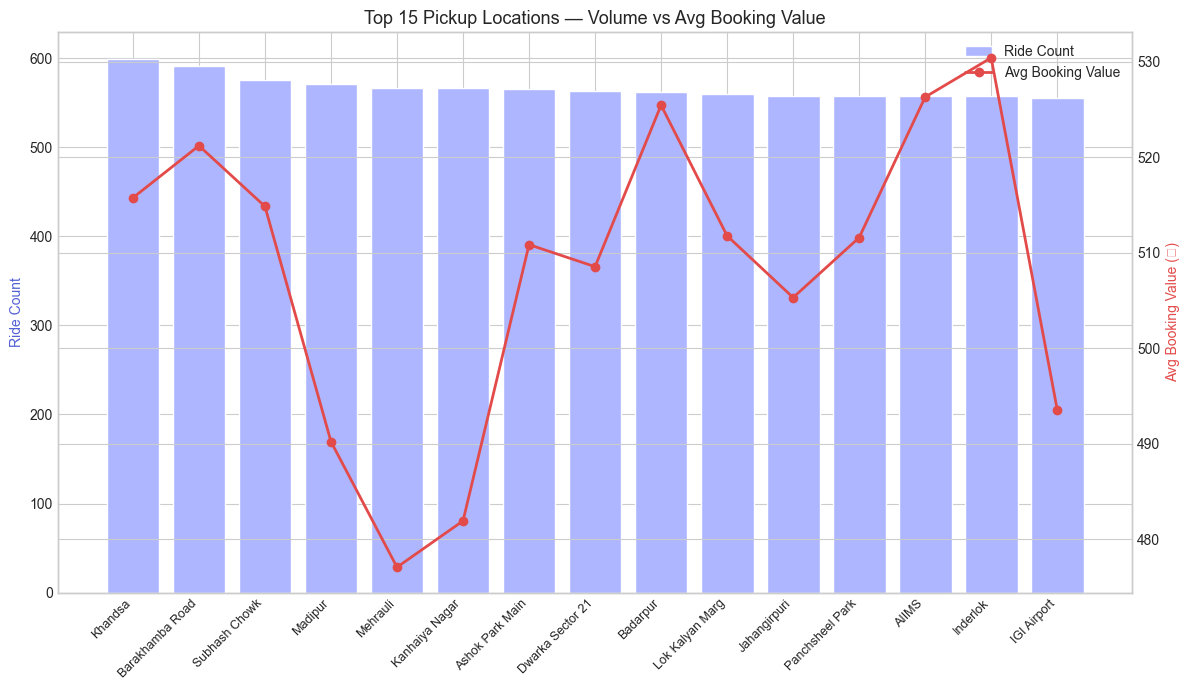

In [62]:
# ── 8.7  Top 15 Pickup Locations — Booking Value and Volume ───────────────
top_locations = (
    df_completed_clean.groupby('Pickup Location')
    .agg(Ride_Count=('Booking ID','count'), Avg_Value=('Booking Value','mean'))
    .nlargest(15, 'Ride_Count')
)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()
x = np.arange(len(top_locations))
ax1.bar(x, top_locations['Ride_Count'], color='#AEB6FF', label='Ride Count', edgecolor='white')
ax2.plot(x, top_locations['Avg_Value'], marker='o', color='#E24B4A', linewidth=2, label='Avg Booking Value')
ax1.set_xticks(x)
ax1.set_xticklabels(top_locations.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Ride Count', color='#5360D4')
ax2.set_ylabel('Avg Booking Value (₹)', color='#E24B4A')
ax1.set_title('Top 15 Pickup Locations — Volume vs Avg Booking Value', fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()
